In [99]:
import pandas as pd
import numpy as np
df=pd.read_csv(r'/content/drive/MyDrive/Datasets/framingham.csv')

In [100]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [101]:
df.isna().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [103]:
df['education']=df['education'].fillna(df['education'].mode()[0])

In [104]:
df['cigsPerDay']=df['cigsPerDay'].fillna(df['cigsPerDay'].mode()[0])

In [105]:
df['BPMeds']=df['BPMeds'].fillna(df['BPMeds'].mode()[0])

In [106]:
df['totChol']=df['totChol'].fillna(df['totChol'].mode()[0])

In [107]:
df['heartRate']=df['totChol'].fillna(df['totChol'].mode()[0])


In [108]:
df['glucose']=df['glucose'].fillna(df['glucose'].mode()[0])

In [109]:
df['BMI']=df['BMI'].fillna(df['BMI'].mean())

In [110]:
df.isna().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


In [111]:
x=df.drop(columns='TenYearCHD')

In [112]:
x

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,195.0,77.0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,250.0,76.0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,245.0,70.0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,225.0,103.0
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,285.0,85.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,248.0,86.0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,210.0,75.0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,269.0,107.0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,185.0,72.0


In [113]:
y=df['TenYearCHD']
y

,TenYearCHD
0,0
1,0
2,0
3,1
4,0
...,...
4235,0
4236,0
4237,0
4238,0


In [114]:
from sklearn.model_selection import train_test_split
x_tr,x_te,y_tr,y_te=train_test_split(x,y,train_size=0.70,random_state=13)

In [115]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
x_tr_scaled=scale.fit_transform(x_tr)
x_te_scaled=scale.transform(x_te)

In [116]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_tr_scaled,y_tr)
y_pred=knn.predict(x_te_scaled)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [117]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print(classification_report(y_te,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91      1068
           1       0.40      0.10      0.16       204

    accuracy                           0.83      1272
   macro avg       0.62      0.53      0.53      1272
weighted avg       0.78      0.83      0.79      1272



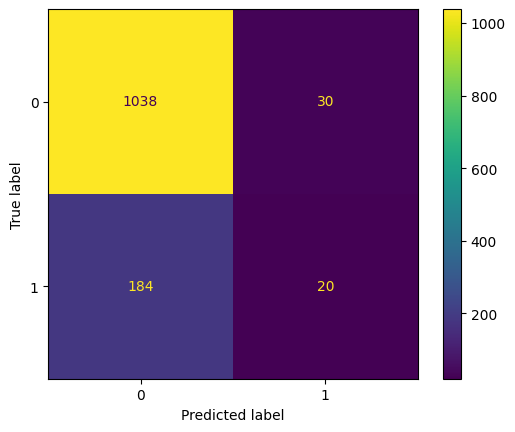

In [118]:
print(ConfusionMatrixDisplay.from_predictions(y_te,y_pred))

In [119]:
from sklearn.naive_bayes import GaussianNB
gnb=GaussianNB()
gnb.fit(x_tr,y_tr)
y_pred_gnb=gnb.predict(x_te)

In [120]:
print(classification_report(y_te,y_pred_gnb))

              precision    recall  f1-score   support

           0       0.86      0.93      0.89      1068
           1       0.37      0.22      0.28       204

    accuracy                           0.81      1272
   macro avg       0.61      0.57      0.58      1272
weighted avg       0.78      0.81      0.79      1272



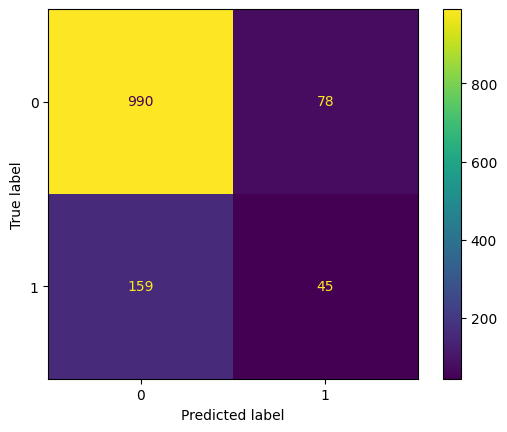

In [121]:
print(ConfusionMatrixDisplay.from_predictions(y_te,y_pred_gnb))

In [122]:
y_knn=knn.predict(scale.transform([[1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0]]))
if y_knn==0:
  print('no heart issues')
else:
  print("RIP")

no heart issues


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [123]:
y_gnb=gnb.predict([[1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0]])
if y_gnb==0:
  print('no heart issues')
else:
  print("RIP")

no heart issues


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [124]:
from imblearn.under_sampling import RandomUnderSampler
us=RandomUnderSampler(random_state=11)
x_us,y_us=us.fit_resample(x_tr,y_tr)

In [127]:
gnb_us=GaussianNB()
gnb_us.fit(x_us,y_us)
y_pred_gnb_us=gnb_us.predict(x_te)

In [128]:
print(classification_report(y_te,y_pred_gnb_us))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88      1068
           1       0.35      0.27      0.31       204

    accuracy                           0.80      1272
   macro avg       0.61      0.59      0.60      1272
weighted avg       0.78      0.80      0.79      1272



In [132]:
gnb_us.score(x_tr,y_tr)

0.8173854447439353

In [133]:
gnb_us.score(x_te,y_te)

0.8011006289308176

In [125]:
from imblearn.over_sampling import SMOTE
os=SMOTE(random_state=11)
x_os,y_os=os.fit_resample(x_tr,y_tr)

In [129]:
gnb_os=GaussianNB()
gnb_os.fit(x_os,y_os)
y_pred_gnb_os=gnb_os.predict(x_te)

In [130]:
print(classification_report(y_te,y_pred_gnb_os))

              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1068
           1       0.30      0.42      0.35       204

    accuracy                           0.75      1272
   macro avg       0.59      0.62      0.60      1272
weighted avg       0.79      0.75      0.76      1272



In [134]:
gnb_os.score(x_tr,y_tr)

0.751010781671159

In [135]:
gnb_os.score(x_te,y_te)

0.7484276729559748

In [136]:
knn_os=KNeighborsClassifier(n_neighbors=9)
knn_us=KNeighborsClassifier(n_neighbors=9)
x_scale_os,y_knn_os=os.fit_resample(x_tr_scaled,y_tr)
x_scale_us,y_knn_us=us.fit_resample(x_tr_scaled,y_tr)
knn_os.fit(x_scale_os,y_knn_os)
knn_us.fit(x_scale_us,y_knn_us)
y_knn_os=knn_os.predict(x_te_scaled)
y_knn_us=knn_us.predict(x_te_scaled)

In [137]:
print(classification_report(y_te,y_knn_os))

              precision    recall  f1-score   support

           0       0.90      0.64      0.75      1068
           1       0.25      0.61      0.35       204

    accuracy                           0.64      1272
   macro avg       0.57      0.63      0.55      1272
weighted avg       0.79      0.64      0.69      1272



In [139]:
knn_os.score(x_tr_scaled,y_tr)

0.7179919137466307

In [141]:
knn_os.score(x_te_scaled,y_te)

0.6391509433962265

In [138]:
print(classification_report(y_te,y_knn_us))

              precision    recall  f1-score   support

           0       0.89      0.64      0.75      1068
           1       0.24      0.58      0.34       204

    accuracy                           0.63      1272
   macro avg       0.56      0.61      0.54      1272
weighted avg       0.79      0.63      0.68      1272



In [142]:
knn_us.score(x_tr_scaled,y_tr)

0.6775606469002695

In [140]:
knn_us.score(x_te_scaled,y_te)

0.6344339622641509